# Car Price Prediction with Machine Learning

## Project Overview

Car prices depend on various factors such as brand, engine power, mileage, fuel type, transmission, and other vehicle characteristics. In this project, machine learning techniques are used to analyze these factors and predict the selling price of cars.

The project includes data cleaning, exploratory data analysis, feature engineering, preprocessing, regression model training, and evaluation.

## Objectives

1. Analyze the factors that influence car prices.
2. Clean and prepare the dataset for analysis.
3. Explore patterns and relationships between car features and price.
4. Perform feature engineering and data preprocessing.
5. Train and compare regression models.
6. Evaluate model performance using suitable metrics.
7. Use the best-performing model to predict car prices.

## Libraries Used

- **Pandas**: Data loading, cleaning, and manipulation
- **NumPy**: Numerical operations
- **Matplotlib**: Data visualization
- **Seaborn**: Statistical visualization
- **Scikit-learn**: Data preprocessing, regression models, and evaluation

In [1]:
import sys
sys.path.append(r"D:\Lib\site-packages")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import zipfile
with zipfile.ZipFile("car.zip", "r") as zip_ref:
    zip_ref.extractall()

In [5]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Initial Data Understanding

Before cleaning and analyzing the dataset, we first examine its structure, columns, size, data types, and basic statistics.

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (301, 9)


In [7]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [8]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Data Quality Check

The dataset is checked for missing values and duplicate records before further analysis. This helps identify data quality issues that need to be addressed during preprocessing.

In [10]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


## Data Cleaning

The dataset is cleaned by removing unnecessary spaces from column names, handling missing values, and removing duplicate records. This ensures that the data is consistent and ready for further analysis.

In [12]:
df.columns = df.columns.str.strip()

print("Cleaned Columns:")
print(df.columns.tolist())

Cleaned Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [13]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [15]:
df = df.dropna()

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [16]:
df = df.drop_duplicates()

print("Duplicate Rows After Cleaning:", df.duplicated().sum())

Duplicate Rows After Cleaning: 0


In [17]:
print("Cleaned Dataset Shape:", df.shape)
df.head()

Cleaned Dataset Shape: (299, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Exploratory Data Analysis

Exploratory data analysis is performed to understand the distribution of car prices and examine how different features are related to the selling price.

### Price Distribution

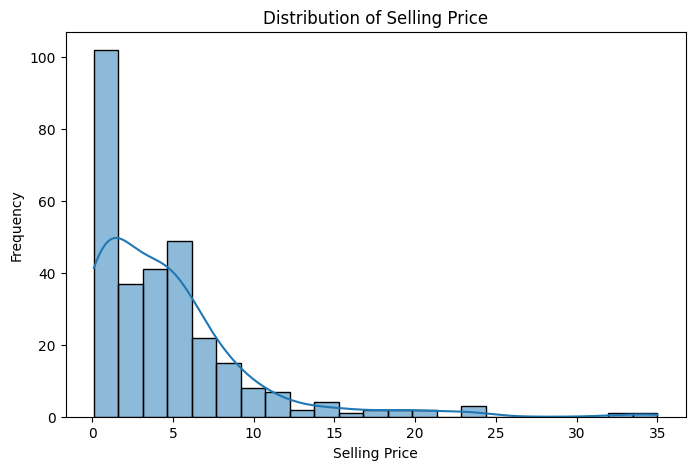

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

**Observation**

The distribution is heavily right-skewed, showing that most selling prices are concentrated at the lower end (between 0 and 5). A long tail extends toward higher values up to 35, indicating that high-priced items occur much less frequently.

### Categorical Feature Analysis

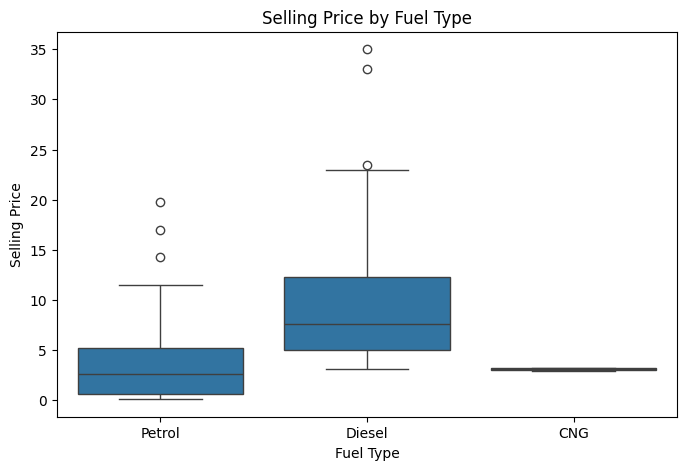

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

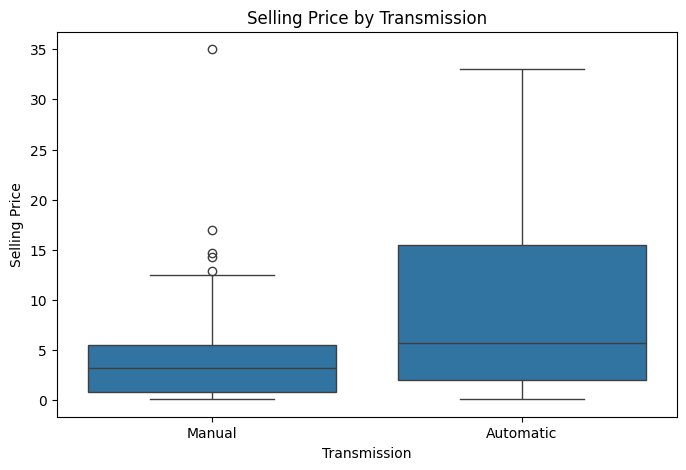

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Transmission", y="Selling_Price", data=df)
plt.title("Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.show()

**Observation**

- Diesel cars generally command higher selling prices and a wider interquartile range compared to Petrol and CNG vehicles.   
- Automatic transmission vehicles exhibit a higher median selling price and greater upper-range variability than manual transmission cars.

### Relationship Between Present Price and Selling Price

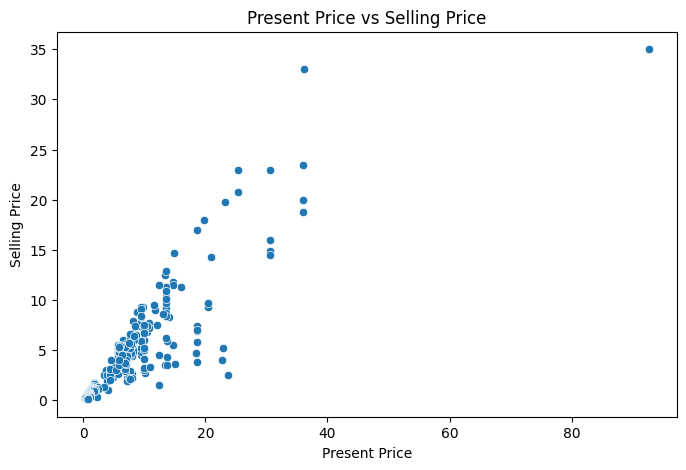

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Present_Price", y="Selling_Price", data=df)
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

**Observation**

- The scatter plot reveals a strong positive correlation between a car's present price and its selling price.  
- As the present price increases, the selling price also scales upward, with most data points clustered densely at lower price ranges and higher-valued outliers extending outward.   

### Relationship Between Car Age and Selling Price

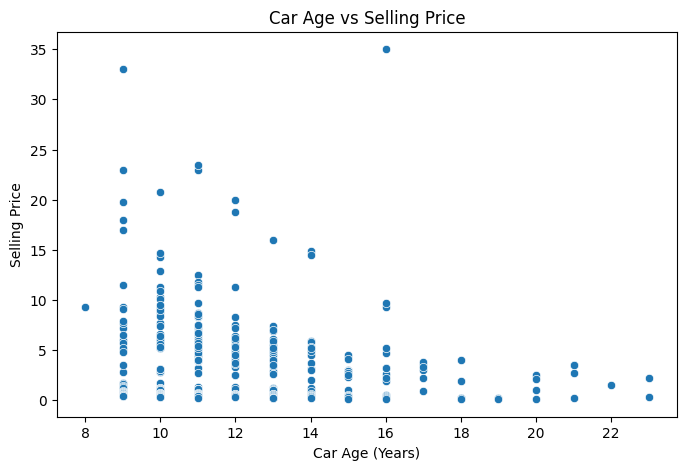

In [23]:
current_year = 2026
df["Car_Age"] = current_year - df["Year"]

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()

**Observation**

The scatter plot demonstrates a negative relationship between car age and selling price, showing that older vehicles generally command lower selling prices with higher-valued cars concentrated among newer model years.

## Feature Engineering

Feature engineering is performed to create useful features from the existing data and prepare the dataset for machine learning.

### Creating Car Age

In [24]:
current_year = 2026
df["Car_Age"] = current_year - df["Year"]

df[["Year", "Car_Age", "Selling_Price"]].head()

,Year,Car_Age,Selling_Price
0,2014,12,3.35
1,2013,13,4.75
2,2017,9,7.25
3,2011,15,2.85
4,2014,12,4.60


### Selecting Relevant Features

The relevant numerical and categorical features are selected for predicting the selling price.

In [27]:
features = [
    "Present_Price",
    "Driven_kms",
    "Fuel_Type",
    "Selling_type",
    "Transmission",
    "Owner",
    "Car_Age"
]

X = df[features]
y = df["Selling_Price"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']

Target:
Selling_Price


## Data Preprocessing

The selected categorical features are converted into numerical form so that they can be used by machine learning regression models.

### Encoding Categorical Features

Categorical variables such as fuel type, selling type, and transmission are encoded using dummy variables.

In [28]:
X = pd.get_dummies(
    X,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

X.head()

,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,5.59,27000,0,12,False,True,False,True
1,9.54,43000,0,13,True,False,False,True
2,9.85,6900,0,9,False,True,False,True
3,4.15,5200,0,15,False,True,False,True
4,6.87,42450,0,12,True,False,False,True


## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (239, 8)
Testing Data: (60, 8)


**Observation**

The dataset is split into a training set with 239 rows and 8 columns and a testing set containing 60 rows and 8 columns, featuring one-hot encoded and numerical attributes like Present_Price, Car_Age, and Transmission.

## Model Training

Three regression models are trained to predict car selling prices. Using multiple models allows us to compare their performance and identify the model that works best for this dataset.

### Regression Models

The following regression algorithms are used:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Training the Models

Each model is trained using the training dataset and then used to predict selling prices for the test dataset.

In [31]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


## Model Evaluation and Comparison

The trained models are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. These metrics help compare how accurately each model predicts car selling prices.

### Evaluation Metrics

1. MAE: measures the average prediction error.
2. RMSE: gives more weight to larger prediction errors.
3. R² Score: shows how well the model explains the variation in selling prices.

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    y_pred = predictions[name]

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.472546,2.524505,0.752723
1,Decision Tree,1.108500,2.105621,0.827975
2,Random Forest,1.465638,3.509593,0.522092


**Observation**

The Decision Tree model achieves the best overall performance with the lowest MAE (1.11) and RMSE (2.11) alongside the highest $R^2$ Score (0.83), outperforming both Linear Regression and Random Forest.

### Model Comparison

The R² scores are visualized to make the performance differences between the models easier to compare.

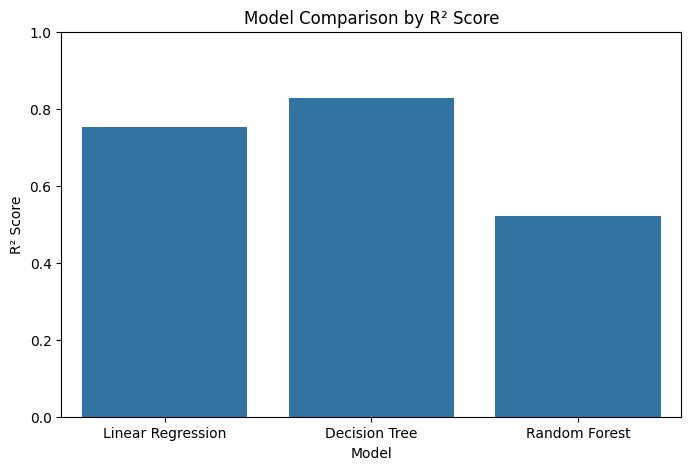

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df
)

plt.title("Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

**Observation**

The bar chart compares the $R^2$ scores of Linear Regression, Decision Tree, and Random Forest, showing that the Decision Tree achieves the highest score of approximately 0.83, thereby outperforming the other two models.   

## Best Model Selection

The model with the highest R² Score is selected as the best-performing model for predicting car selling prices.

In [34]:
best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(), "Model"
]

best_model = models[best_model_name]

best_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("Best Model:", best_model_name)
print("MAE:", round(best_result["MAE"], 4))
print("RMSE:", round(best_result["RMSE"], 4))
print("R² Score:", round(best_result["R2 Score"], 4))

Best Model: Decision Tree
MAE: 1.1085
RMSE: 2.1056
R² Score: 0.828


**Observation**

The Decision Tree has been selected as the best-performing model, achieving a final evaluation with an MAE of 1.11, an RMSE of 2.11, and an $R^2$ Score of 0.83.

## Actual vs Predicted Prices

The actual and predicted selling prices are compared visually to examine how closely the selected model's predictions match the real prices.

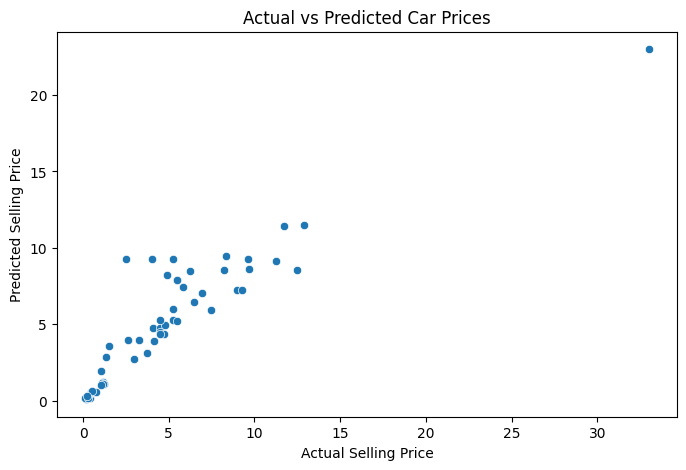

In [35]:
best_predictions = predictions[best_model_name]

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=best_predictions)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.show()

**Observation**

The scatter plot compares actual versus predicted car prices, showing that most points cluster near the diagonal line with a high actual and predicted value reaching 33, indicating that the Decision Tree model makes reasonably accurate predictions with minor deviations.

## Key Findings

The analysis of the car dataset produced the following key findings:

1. The selling price distribution is right-skewed, with most cars concentrated in the lower price range.
2. Present price shows a strong positive relationship with selling price.
3. Car age shows a negative relationship with selling price, indicating that older cars generally have lower selling prices.
4. Differences in selling prices can also be observed across fuel type and transmission categories.
5. After cleaning, the dataset contained 299 records with no missing values or duplicate rows.
6. Among the three tested models, the Decision Tree achieved the highest R² Score and the lowest MAE and RMSE.

## Final Conclusion

This project used machine learning to predict car selling prices based on vehicle characteristics such as present price, driven kilometers, fuel type, selling type, transmission, ownership, and car age.

The dataset was cleaned and explored to identify important patterns and relationships. Feature engineering was used to create the Car_Age feature, while categorical variables were converted into numerical form using dummy encoding.

Three regression models were trained and evaluated: Linear Regression, Decision Tree, and Random Forest. The Decision Tree achieved the best performance with an MAE of 1.11, an RMSE of 2.11, and an R² Score of 0.83.

Overall, the results show that machine learning can effectively model car selling prices, with the Decision Tree providing the strongest predictive performance among the models tested on this dataset.